In [256]:
import pandas as pd
import pickle
import os
from glob import glob
import numpy as np
from llama_cpp import Llama
import re
ruta_pkl = "./"  
archivos = ['results.pkl']
lista_features = []
for archivo in archivos:
    try:
        with open(archivo, "rb") as f:
            contenido = pickle.load(f)
            features = list(contenido['features'].variable)
            lista_features=lista_features+features
    except Exception as e:
        print(f"[ERROR] Falló al procesar {archivo}: {e}")
lista_features=np.unique(lista_features)
df = pd.read_pickle("data_family.pkl")
exog = df['exog'].copy().ffill()[lista_features]
exog

,ExtremoSur_tavg,Primavera,al,bienos_no_durables,consumo_hogar_ipsfl,cu,hierro_fob,imacec,imacec_no_minero,ipc_sin_volatiles_mensual,molibdeno_fob,movilidad,tasa_int_prom_vivienda,zn
dt,,,,,,,,,,,,,,
2017-01-01,12.727419,0.0,0.824864,12724.080283,28946.866181,2.7745,99.505775,92.487586,92.663595,0.368022,13.004495,0.0,3.62,1.300817
2017-02-01,13.964286,0.0,0.873412,12538.999373,28589.568748,2.7760,68.453212,89.066912,90.143487,0.319418,16.742961,0.0,3.55,1.279946
2017-03-01,11.283871,0.0,0.891221,12168.837554,27874.973884,2.7420,91.434381,100.353074,102.285871,0.584359,21.760297,0.0,3.47,1.255898
2017-04-01,8.556667,0.0,0.867173,11917.152951,27484.550588,2.6810,74.299944,95.345691,96.243721,0.477543,11.422112,0.0,3.42,1.190336
2017-05-01,6.253226,0.0,0.874660,11783.945565,27418.298860,2.6575,60.546277,96.953323,97.280222,0.105915,16.540103,0.0,3.36,1.179673
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,5.011290,0.0,1.062840,12979.360750,31876.078818,4.1450,127.793228,109.512246,111.685315,0.096739,23.865209,0.0,4.97,1.130469
2024-09-01,5.691667,0.5,1.149841,12986.180026,31796.265131,4.4960,125.699035,105.270940,106.938772,0.339036,13.509175,0.0,4.81,1.142813
2024-10-01,10.109677,1.0,1.161751,12986.180026,31796.265131,4.3135,87.044803,110.577523,112.986265,0.412874,49.409920,0.0,4.54,1.104688


In [ ]:
import pandas as pd
name='0105'
df_results = pd.read_pickle(f"results.pkl")
best_models = (
    df_results['trials']
    .sort_values('mape_mean')
    .groupby('model', as_index=False)
    .first()
    .sort_values('mape_mean')
    .reset_index(drop=True)
)
best_models.to_csv("mejores_modelos_por_mape.csv", index=False)
best_models.sort_values('mape_mean')

,model,trial_number,params,mape_mean,mape_best
0,MLP,12,"{'hidden_layer_sizes': (256, 128), 'max_iter':...",0.056513,0.040847
1,Prophet,48,"{'growth': 'linear', 'seasonality_prior_scale'...",0.060308,0.039513
2,LSTM,46,"{'window_size': 8, 'units': 123, 'epochs': 89,...",0.066609,0.051246
3,EXOG-LSTM,92,"{'hidden_size': 36, 'num_layers': 4, 'dropout'...",0.088774,0.072572
4,GPT2,49,"{'context_length': 61, 'prediction_length': 11}",0.090044,0.058320
5,HW,41,"{'trend': None, 'seasonal': 'add', 'seasonal_p...",0.096781,0.059214
6,OLLAMA-GGUF,10,"{'context_length': 72, 'prediction_length': 9,...",0.108558,0.079701


In [292]:
model_results.iloc[i].params

{'hidden_size': 38,
 'num_layers': 4,
 'dropout': 0.06310424971500089,
 'seq_len': 21,
 'epochs': 98,
 'lr': 0.00011880672246829821,
 'batch_size': 32}

/var/folders/_2/b07hnlxx27j566j7xpz5w05m0000gn/T/ipykernel_70513/3226317850.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


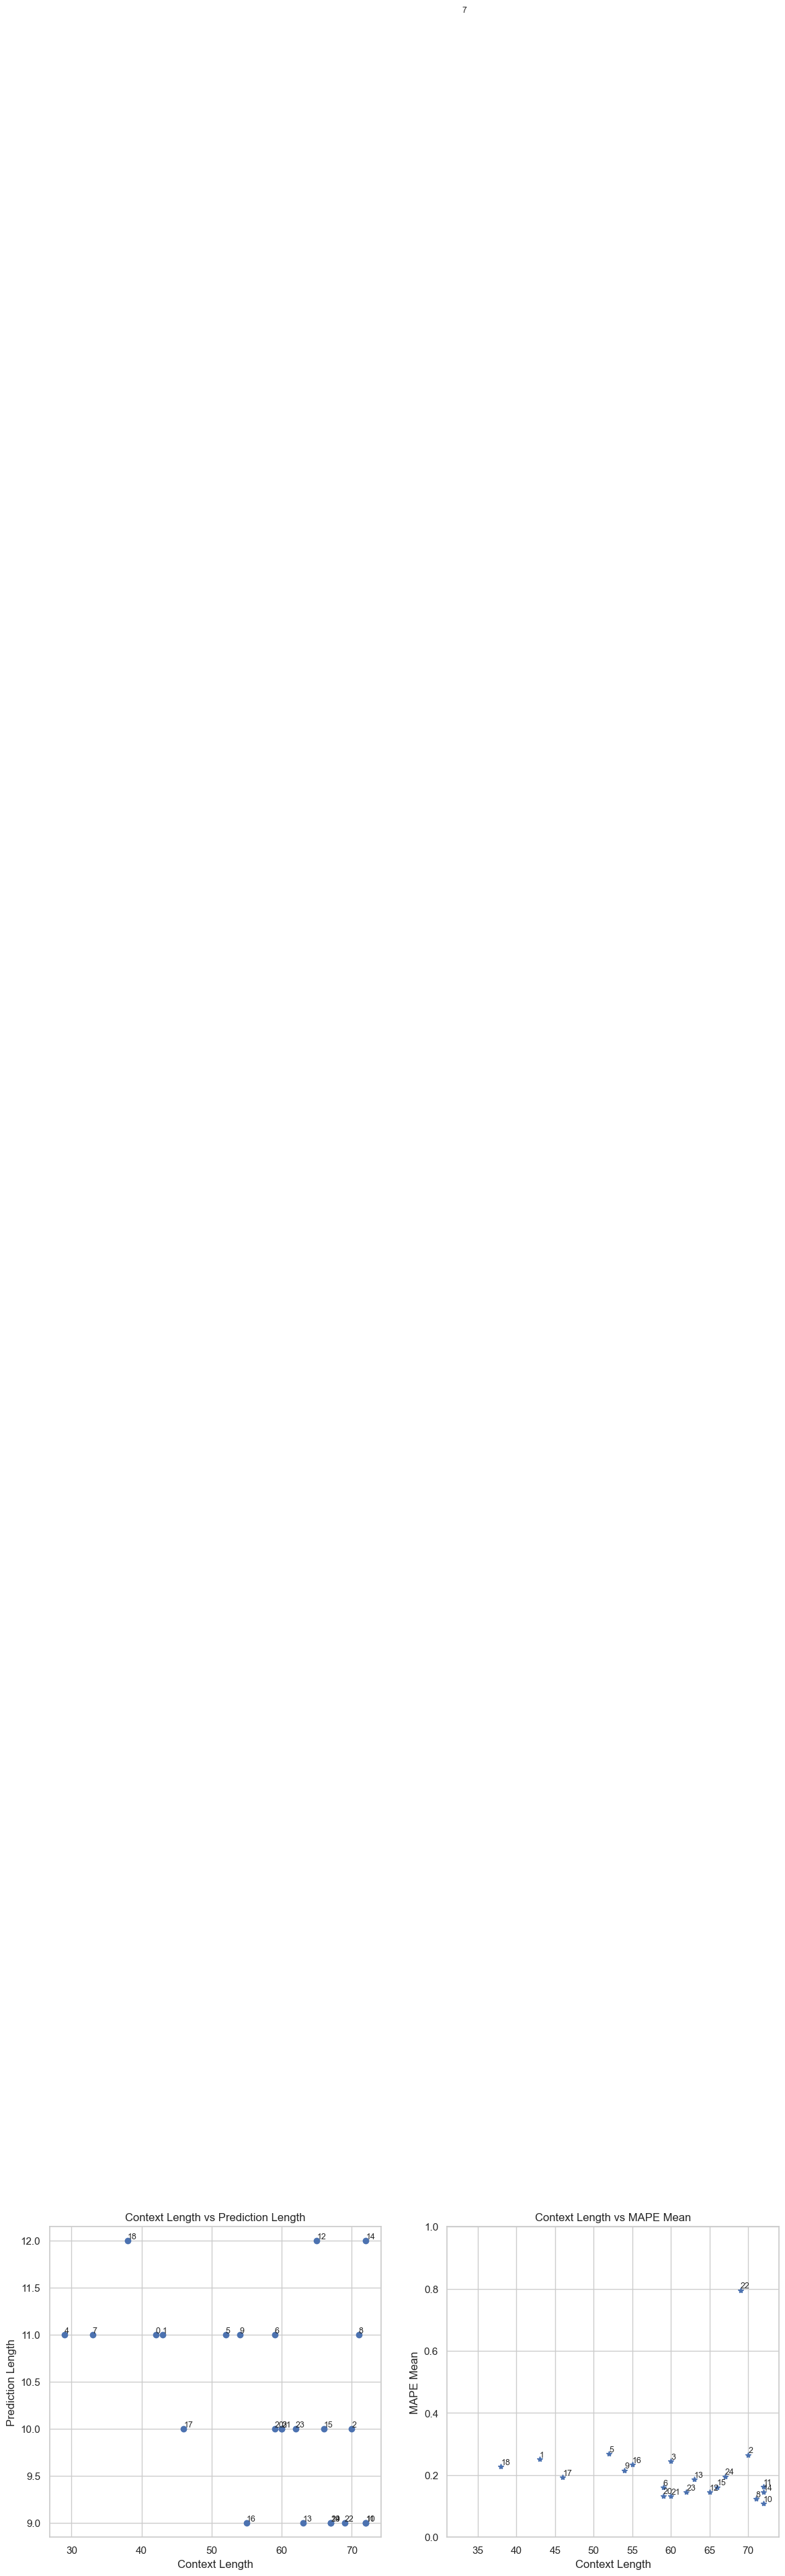

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

name = '0105'
df_results = pd.read_pickle("results.pkl")
model_results = df_results['trials'][df_results['trials'].model == 'OLLAMA-GGUF']

context_length = []
mape_mean = []
prediction_length = []

for i in range(len(model_results)):
    context_length.append(model_results.iloc[i].params['context_length'])
    prediction_length.append(model_results.iloc[i].params['prediction_length'])
    mape_mean.append(model_results.iloc[i].mape_mean)

results = pd.DataFrame({
    'context_length': context_length,
    'prediction_length': prediction_length,
    'mape_mean': mape_mean,
    'name': list(range(len(context_length)))
})

results = results.sort_values('context_length')

# Crear dos subplots en una sola fila
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Primer gráfico: context_length vs prediction_length con etiquetas
axes[0].plot(results.context_length, results.prediction_length, 'o')
for i in range(len(results)):
    x = results.context_length.iloc[i]
    y = results.prediction_length.iloc[i]
    label = str(results.name.iloc[i])
    axes[0].text(x, y, label, fontsize=9, ha='left', va='bottom')

axes[0].set_title('Context Length vs Prediction Length')
axes[0].set_xlabel('Context Length')
axes[0].set_ylabel('Prediction Length')
axes[0].grid(True)

# Segundo gráfico: context_length vs mape_mean con etiquetas
axes[1].plot(results.context_length, results.mape_mean, '*')
for i in range(len(results)):
    x = results.context_length.iloc[i]
    y = results.mape_mean.iloc[i]
    label = str(results.name.iloc[i])
    axes[1].text(x, y, label, fontsize=9, ha='left', va='bottom')

axes[1].set_title('Context Length vs MAPE Mean')
axes[1].set_xlabel('Context Length')
axes[1].set_ylabel('MAPE Mean')
axes[1].set_ylim([0,1])
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [267]:
best_models.params.values

array([{'hidden_layer_sizes': (256, 128), 'max_iter': 1000},
       {'growth': 'linear', 'seasonality_prior_scale': 4.649491318897596, 'seasonality_mode': 'multiplicative', 'holidays_prior_scale': 8.759992291542781, 'changepoint_prior_scale': 0.9489691152886376, 'n_changepoints': 42},
       {'window_size': 8, 'units': 123, 'epochs': 89, 'batch_size': 32, 'learning_rate': 0.0014733812939759607},
       {'hidden_size': 36, 'num_layers': 4, 'dropout': 0.24494303589828686, 'seq_len': 23, 'epochs': 22, 'lr': 0.00014195892199230748, 'batch_size': 32, 'input_size_seq': 1, 'input_size_exog': 15},
       {'context_length': 61, 'prediction_length': 11},
       {'trend': None, 'seasonal': 'add', 'seasonal_periods': 24},
       {'context_length': 72, 'prediction_length': 9, 'normalize': True}],
      dtype=object)

In [259]:
from sklearn.preprocessing import MinMaxScaler
from transformers import AutoTokenizer, AutoModelForCausalLM
import numpy as np
import pandas as pd
import torch
_llm_model = None
_tokenizer = None
def fit_predict_eval_llm_forecaster(training_set, test_set, model_params=None):
    """
    Simula la predicción de series de tiempo usando un LLM como si fuera un modelo de forecasting.
    Transforma la serie temporal a texto, el modelo predice tokens que representan valores futuros.
    """
    global _llm_model, _tokenizer

    default_params = {
        'context_length': 128,
        'prediction_length': 24,
        'model_name': 'gpt2'  # o uno de huggingface como mistralai/Mistral-7B-Instruct-v0.2
    }
    if model_params:
        default_params.update(model_params)
    p = default_params

    scaler_y = MinMaxScaler()
    y_train = scaler_y.fit_transform(training_set[['y']]).flatten()
    y_test = scaler_y.transform(test_set[['y']]).flatten()
    y_all = np.concatenate([y_train, y_test])

    total_required_length = p['context_length'] + p['prediction_length']
    if len(y_all) < total_required_length:
        raise ValueError("No hay suficientes datos para el contexto y predicción requeridos.")

    # Inicializa el modelo y tokenizer
    if _llm_model is None or _tokenizer is None:
        _tokenizer = AutoTokenizer.from_pretrained(p['model_name'])
        _llm_model = AutoModelForCausalLM.from_pretrained(p['model_name'])

    # Codifica la serie como texto (e.g., coma separada)
    context_series = y_all[-total_required_length:-p['prediction_length']]
    context_str = ", ".join([f"{v:.3f}" for v in context_series])
    prompt = f"Given the previous values: [{context_str}], predict the next {p['prediction_length']} values:"

    inputs = _tokenizer(prompt, return_tensors="pt")
    with torch.no_grad():
        outputs = _llm_model.generate(**inputs, max_new_tokens=50, pad_token_id=_tokenizer.eos_token_id)

    decoded = _tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Extraer los números predichos desde el texto (simple parsing, no robusto)
    import re
    predicted_str = decoded.split("predict the next")[1]
    predicted_values = re.findall(r"\d+\.\d+", predicted_str)
    y_pred_scaled = np.array(predicted_values[:p['prediction_length']], dtype=float)

    # Inversa del escalamiento
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    index_pred = test_set.index[:len(y_pred)]
    return _llm_model, pd.Series(y_pred, index=index_pred, name='LLMForecast'), scaler_y


_llm_gguf_model = None  # Global para evitar recarga

def fit_predict_eval_llm_forecaster_gguf(training_set, test_set, model_params=None):
    """
    Simula la predicción de series de tiempo usando un LLM en formato .gguf.
    Si normalize=True, aplica MinMaxScaler. Si no, usa los valores reales.
    """
    global _llm_gguf_model

    default_params = {
        'context_length': 128,
        'prediction_length': 24,
        'model_path': './models/llama-2-7b.Q4_K_M.gguf',
        'max_tokens': 256,
        'n_ctx': 2048,
        'normalize': False
    }
    if model_params:
        default_params.update(model_params)
    p = default_params

    # Validar tamaño
    if p['prediction_length'] > len(test_set):
        raise ValueError(f"prediction_length ({p['prediction_length']}) > test_set ({len(test_set)}).")

    # Normalizar si se indica
    if p['normalize']:
        scaler_y = MinMaxScaler()
        if training_set[['y']].dropna().empty:
            raise ValueError("training_set['y'] está vacío o solo tiene NaN")

        y_train = scaler_y.fit_transform(training_set[['y']]).flatten()
        y_test = scaler_y.transform(test_set[['y']]).flatten()
        y_all = np.concatenate([y_train, y_test])
    else:
        scaler_y = None
        y_train = training_set['y'].values
        y_test = test_set['y'].values
        y_all = np.concatenate([y_train, y_test])

    total_required_length = p['context_length'] + p['prediction_length']
    if len(y_all) < total_required_length:
        raise ValueError("No hay suficientes datos para contexto + predicción.")

    # Cargar modelo solo una vez
    if _llm_gguf_model is None:
        _llm_gguf_model = Llama(model_path=p['model_path'], n_ctx=p['n_ctx'])

    # Crear prompt con ejemplo opcional
    context_series = y_all[-total_required_length:-p['prediction_length']]
    context_str = ", ".join([f"{v:.3f}" for v in context_series])
    prompt = (
        f"Example:\n"
        f"Input: 0.2, 0.3, 0.4\n"
        f"Output: 0.5, 0.6, 0.7\n\n"
        f"Input: {context_str}\n"
        f"Output:"
    )

    output = _llm_gguf_model(prompt, max_tokens=p['max_tokens'], echo=False)
    generated_text = output['choices'][0]['text'].strip()

    # Extraer números
    predicted_values = re.findall(r"\d+\.\d+", generated_text)
    if not predicted_values:
        raise ValueError("El modelo no generó ningún número reconocible.")

    y_pred_raw = np.array(predicted_values, dtype=float)

    # Limitar al tamaño de test_set
    n_values = min(len(y_pred_raw), len(test_set), p['prediction_length'])

    if scaler_y:
        y_pred = scaler_y.inverse_transform(y_pred_raw[:n_values].reshape(-1, 1)).flatten()
    else:
        y_pred = y_pred_raw[:n_values]

    index_pred = test_set.index[:n_values]

    return _llm_gguf_model, pd.Series(y_pred, index=index_pred, name='LLMForecast_GGUF'), scaler_y
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

class LSTMExogenous(nn.Module):
    def __init__(self, input_size_seq, input_size_exog, hidden_size=64,
                 num_layers=1, dropout=0.2, prediction_length=6):
        super().__init__()
        self.lstm = nn.LSTM(input_size_seq, hidden_size, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc_exog = nn.Linear(input_size_exog, hidden_size)
        self.fc_out = nn.Linear(hidden_size * 2, prediction_length)

    def forward(self, x_seq, x_exog):
        lstm_out, _ = self.lstm(x_seq)
        lstm_last = lstm_out[:, -1, :]
        exog_out = torch.relu(self.fc_exog(x_exog))
        combined = torch.cat([lstm_last, exog_out], dim=1)
        output = self.fc_out(combined)
        return output

def fit_predict_eval_EXlstm(training_set, test_set, model_params=None,
                          seq_len=12, prediction_length=6,
                          epochs=50, lr=0.001, batch_size=32):
    default_params = dict(
        input_size_seq=1,
        input_size_exog=len(training_set.columns.difference(['ds', 'y'])),
        hidden_size=64,
        num_layers=1,
        dropout=0.2
    )

    model_params.setdefault('input_size_seq', 1)
    model_params.setdefault('input_size_exog', len(training_set.columns.difference(['ds', 'y'])))

    if model_params:
        default_params.update(model_params)


    scaler_y = StandardScaler()
    scaler_exog = StandardScaler()

    def build_sequences(df):
        y_scaled = scaler_y.fit_transform(df[['y']])
        exog_scaled = scaler_exog.fit_transform(df.drop(columns=['ds', 'y']))

        seqs, exogs, targets = [], [], []
        for i in range(len(df) - seq_len - prediction_length + 1):
            seqs.append(y_scaled[i:i+seq_len])
            exogs.append(exog_scaled[i+seq_len])
            targets.append(y_scaled[i+seq_len:i+seq_len+prediction_length].flatten())

        return (torch.tensor(seqs, dtype=torch.float32),
                torch.tensor(exogs, dtype=torch.float32),
                torch.tensor(targets, dtype=torch.float32))

    x_seq_train, x_exog_train, y_train = build_sequences(training_set)
    x_seq_test, x_exog_test, y_test = build_sequences(
        pd.concat([training_set.tail(seq_len + prediction_length - 1), test_set])
    )

    train_ds = TensorDataset(x_seq_train, x_exog_train, y_train)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    excluded_keys = ['seq_len', 'epochs', 'lr', 'batch_size']
    clean_params = {k: v for k, v in model_params.items() if k not in excluded_keys}

    model = LSTMExogenous(**clean_params, prediction_length=prediction_length)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    model.train()
    for epoch in range(epochs):
        for xb_seq, xb_exog, yb in train_dl:
            optimizer.zero_grad()
            preds = model(xb_seq, xb_exog)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(x_seq_test, x_exog_test).numpy()
        preds_inv = scaler_y.inverse_transform(preds)

    # Corregir el index de predicciones
    pred_index = test_set['ds'].reset_index(drop=True)
    pred_dates = pred_index.iloc[:len(preds_inv)]  # evita KeyError

    columns = [f"step_{i+1}" for i in range(prediction_length)]
    predictions = pd.DataFrame(preds_inv, index=pred_dates, columns=columns)

    return model, predictions, None

ggml_metal_free: deallocating
ggml_metal_mem_pool_free: freeing memory pool, num heaps = 0 (total = 0)
ggml_metal_mem_pool_free: freeing memory pool, num heaps = 0 (total = 0)
ggml_metal_mem_pool_free: freeing memory pool, num heaps = 0 (total = 0)
ggml_metal_mem_pool_free: freeing memory pool, num heaps = 0 (total = 0)
ggml_metal_mem_pool_free: freeing memory pool, num heaps = 0 (total = 0)
ggml_metal_mem_pool_free: freeing memory pool, num heaps = 0 (total = 0)
ggml_metal_mem_pool_free: freeing memory pool, num heaps = 0 (total = 0)
ggml_metal_mem_pool_free: freeing memory pool, num heaps = 0 (total = 0)


In [260]:
from aux import *
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error
from models import *
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

df = pd.read_pickle("data_family.pkl")
exog = df['exog'].copy().ffill()
sales_by_family = df['sales_by_family']
familias = pd.read_csv("familias.csv")
data_by_family = {
    fam: format_as_year_month(sales_by_family[sales_by_family['family'] == fam].copy())
    for fam in sales_by_family['family'].unique()
}
#for fam in data_by_family:
#    data_by_family[fam], _ = limpiar_outliers_x_agrupacion(data_by_family[fam], 'family', 'sale_amount_MM')
target_col = 'sale_amount_MM'
ignore_col = [] 
negatives_reg_col = [] 
df_results = pd.read_pickle(f"results.pkl")
best_models = (
    df_results['trials']
    .sort_values('mape_mean')
    .groupby('model', as_index=False)
    .first()
    .sort_values('mape_mean')
    .reset_index(drop=True)
)
models_results = df_results['trials'].reset_index(drop=True)
models_results = models_results.loc[models_results.groupby('model')['mape_mean'].idxmin()]
funcs = dict(zip(['MLP', 'Prophet', 'LSTM', \
                  'EXOG-LSTM', 'GPT2', 'HW', 'OLLAMA-GGUF'],
            [fit_predict_eval_mlp,fit_predict_eval_prophet,fit_predict_eval_lstm, \
             fit_predict_eval_EXlstm,fit_predict_eval_llm_forecaster,fit_predict_eval_hw, \
             fit_predict_eval_llm_forecaster_gguf]))

#funcs = dict(zip(['LSTM','GPT2'],
#            [fit_predict_eval_lstm,fit_predict_eval_llm_forecaster]))



MODELO='GPT2'
mape_list = []
model_params=models_results.query(f"model == '{MODELO}'")['params'].iloc[0]
features=df_results['features']

if MODELO in ['LSTM','GRU','Transformer','ElasticNet', \
              'Prophet','MLP','RegresionTree','RandomForest', \
              'EXOG-LSTM', 'GPT2', 'HW', 'OLLAMA-GGUF'
              ]:
    df_final=exog[features.variable.to_list()].join(data_by_family[name]['sale_amount_MM']).assign(ds=exog.index)
else:
    df_final=exog[features.variable.to_list()].join(data_by_family[name]['sale_amount_MM'])
df_final['y'] = df_final[target_col]

In [261]:
best_models[best_models.model=='EXOG-LSTM'].params.iloc[0]

{'hidden_size': 36,
 'num_layers': 4,
 'dropout': 0.24494303589828686,
 'seq_len': 23,
 'epochs': 22,
 'lr': 0.00014195892199230748,
 'batch_size': 32}

In [262]:
#del funcs['EXOG-LSTM']
#del funcs[ 'OLLAMA-GGUF']
funcs

{'MLP': <function models.fit_predict_eval_mlp(train_data, test_data, model_params=None)>,
 'Prophet': <function models.fit_predict_eval_prophet(training_set, test_set, model_params=None)>,
 'LSTM': <function models.fit_predict_eval_lstm(training_set, test_set, model_params=None)>,
 'EXOG-LSTM': <function __main__.fit_predict_eval_EXlstm(training_set, test_set, model_params=None, seq_len=12, prediction_length=6, epochs=50, lr=0.001, batch_size=32)>,
 'GPT2': <function __main__.fit_predict_eval_llm_forecaster(training_set, test_set, model_params=None)>,
 'HW': <function models.fit_predict_eval_hw(training_set, test_set, model_params=None)>,
 'OLLAMA-GGUF': <function __main__.fit_predict_eval_llm_forecaster_gguf(training_set, test_set, model_params=None)>}

In [245]:
funcs2={}
funcs2['EXOG-LSTM']=funcs['EXOG-LSTM']
funcs=funcs2
funcs

{'EXOG-LSTM': <function __main__.fit_predict_eval_EXlstm(training_set, test_set, model_params=None, seq_len=12, prediction_length=6, epochs=50, lr=0.001, batch_size=32)>}

In [263]:
start_test_date = pd.to_datetime('2023-12-01')
fechas = pd.date_range(start=start_test_date, end=max(df_final.index), freq='MS')
results = pd.DataFrame(index=fechas)
results.index.name = 'ds'
for idx, var in enumerate(funcs):
    MODELO=var
    mape_list = []
    model_params=models_results.query(f"model == '{MODELO}'")['params'].iloc[0]
    features=df_results['features']
    if MODELO in ['LSTM','GRU','Transformer','ElasticNet', \
              'Prophet','MLP','RegresionTree','RandomForest', \
              'EXOG-LSTM', 'GPT2', 'HW', 'OLLAMA-GGUF'
              ]:
        df_final=exog[features.variable.to_list()].join(data_by_family[name]['sale_amount_MM']).assign(ds=exog.index)
    else:
        df_final=exog[features.variable.to_list()].join(data_by_family[name]['sale_amount_MM'])
    df_final['y'] = df_final[target_col]
    training_set=df_final.copy().loc['2017-05-01':str(start_test_date)]
    test_set=df_final.copy().loc[str(start_test_date)::]
    model, y_pred,scaler = funcs[MODELO](training_set, test_set, model_params)
    y_pred.index=fechas[-len(y_pred)::]
    if MODELO in ['EXOG-LSTM']:
      y_pred=pd.DataFrame(y_pred.mean(axis=1)).rename(columns={0:'EXOG-LSTM'})

    print(MODELO)
    results=results.join(pd.DataFrame(y_pred).drop('ds', errors='ignore',axis=1).rename(columns={'pred_test':MODELO}),how='left')
results=results.dropna()

MLP
2025-07-04 00:40:57 cmdstanpy [DEBUG]: input tempfile: /var/folders/_2/b07hnlxx27j566j7xpz5w05m0000gn/T/tmp55ric7a4/w0fqmeap.json
2025-07-04 00:40:57 cmdstanpy [DEBUG]: input tempfile: /var/folders/_2/b07hnlxx27j566j7xpz5w05m0000gn/T/tmp55ric7a4/k3wxvc5m.json
2025-07-04 00:40:57 cmdstanpy [DEBUG]: idx 0
2025-07-04 00:40:57 cmdstanpy [DEBUG]: running CmdStan, num_threads: None
2025-07-04 00:40:57 cmdstanpy [DEBUG]: CmdStan args: ['/Users/sebastianulloa/.virtualenvs/py310/lib/python3.10/site-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=45673', 'data', 'file=/var/folders/_2/b07hnlxx27j566j7xpz5w05m0000gn/T/tmp55ric7a4/w0fqmeap.json', 'init=/var/folders/_2/b07hnlxx27j566j7xpz5w05m0000gn/T/tmp55ric7a4/k3wxvc5m.json', 'output', 'file=/var/folders/_2/b07hnlxx27j566j7xpz5w05m0000gn/T/tmp55ric7a4/prophet_modelshm7e45_/prophet_model-20250704004057.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']


/Users/sebastianulloa/.virtualenvs/py310/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
00:40:57 - cmdstanpy - INFO - Chain [1] start processing


2025-07-04 00:40:57 cmdstanpy [INFO]: Chain [1] start processing


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
00:41:29 - cmdstanpy - INFO - Chain [1] done processing


2025-07-04 00:41:29 cmdstanpy [INFO]: Chain [1] done processing


...

Prophet
LSTM
EXOG-LSTM


/Users/sebastianulloa/.virtualenvs/py310/lib/python3.10/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
llama_model_load_from_file_impl: using device Metal (Apple M1 Max) - 21803 MiB free
llama_model_loader: loaded meta data with 19 key-value pairs and 291 tensors from ./models/llama-2-7b.Q4_K_M.gguf (version GGUF V2)
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = llama
llama_model_loader: - kv   1:                               general.name str              = LLaMA v2
llama_model_loader: - kv   2:                       llama.context_length u32              = 4096
llama_model_loader: - kv   3:                     llama.embedding_length u32 

GPT2
HW


load_tensors: offloading 0 repeating layers to GPU
load_tensors: offloaded 0/33 layers to GPU
load_tensors:   CPU_Mapped model buffer size =  3891.24 MiB
..................................................................................................
llama_context: constructing llama_context
llama_context: n_seq_max     = 1
llama_context: n_ctx         = 2048
llama_context: n_ctx_per_seq = 2048
llama_context: n_batch       = 512
llama_context: n_ubatch      = 512
llama_context: causal_attn   = 1
llama_context: flash_attn    = 0
llama_context: freq_base     = 10000.0
llama_context: freq_scale    = 1
llama_context: n_ctx_per_seq (2048) < n_ctx_train (4096) -- the full capacity of the model will not be utilized
ggml_metal_init: allocating
ggml_metal_init: found device: Apple M1 Max
ggml_metal_init: picking default device: Apple M1 Max
ggml_metal_load_library: using embedded metal library
ggml_metal_init: GPU name:   Apple M1 Max
ggml_metal_init: GPU family: MTLGPUFamilyApple7  (1007)
gg

OLLAMA-GGUF


In [264]:
results

,MLP,Prophet,LSTM,EXOG-LSTM,LLMForecast,ETS,LLMForecast_GGUF
ds,,,,,,,
2024-04-01,6099.923282,5950.767337,5519.229004,5609.273438,5258.842793,4390.967712,5128.257205
2024-05-01,5289.809594,5551.586782,5433.309570,5622.296387,4928.298022,4478.003734,5218.034797
2024-06-01,4711.041641,4469.892022,5565.388184,5573.342285,4254.966080,3667.171914,5262.923593
2024-07-01,5611.805620,5907.971151,5693.439941,5259.243652,4569.187653,3804.251353,5267.004393
2024-08-01,5354.072939,5828.769246,5719.054688,5539.307129,4960.944419,4891.037722,5320.054788
2024-09-01,5515.425192,5207.979407,5784.600586,5770.132812,4336.582073,4658.310753,5458.801976
2024-10-01,6584.995115,6855.938615,5876.507324,5717.498047,4544.702855,5567.587474,5520.013971
2024-11-01,6609.418453,6511.723602,6077.298828,5625.261230,4724.258039,5677.170460,5577.145166
2024-12-01,6404.552642,6139.378590,6177.182617,5730.479004,4789.550834,5221.474228,5597.549164


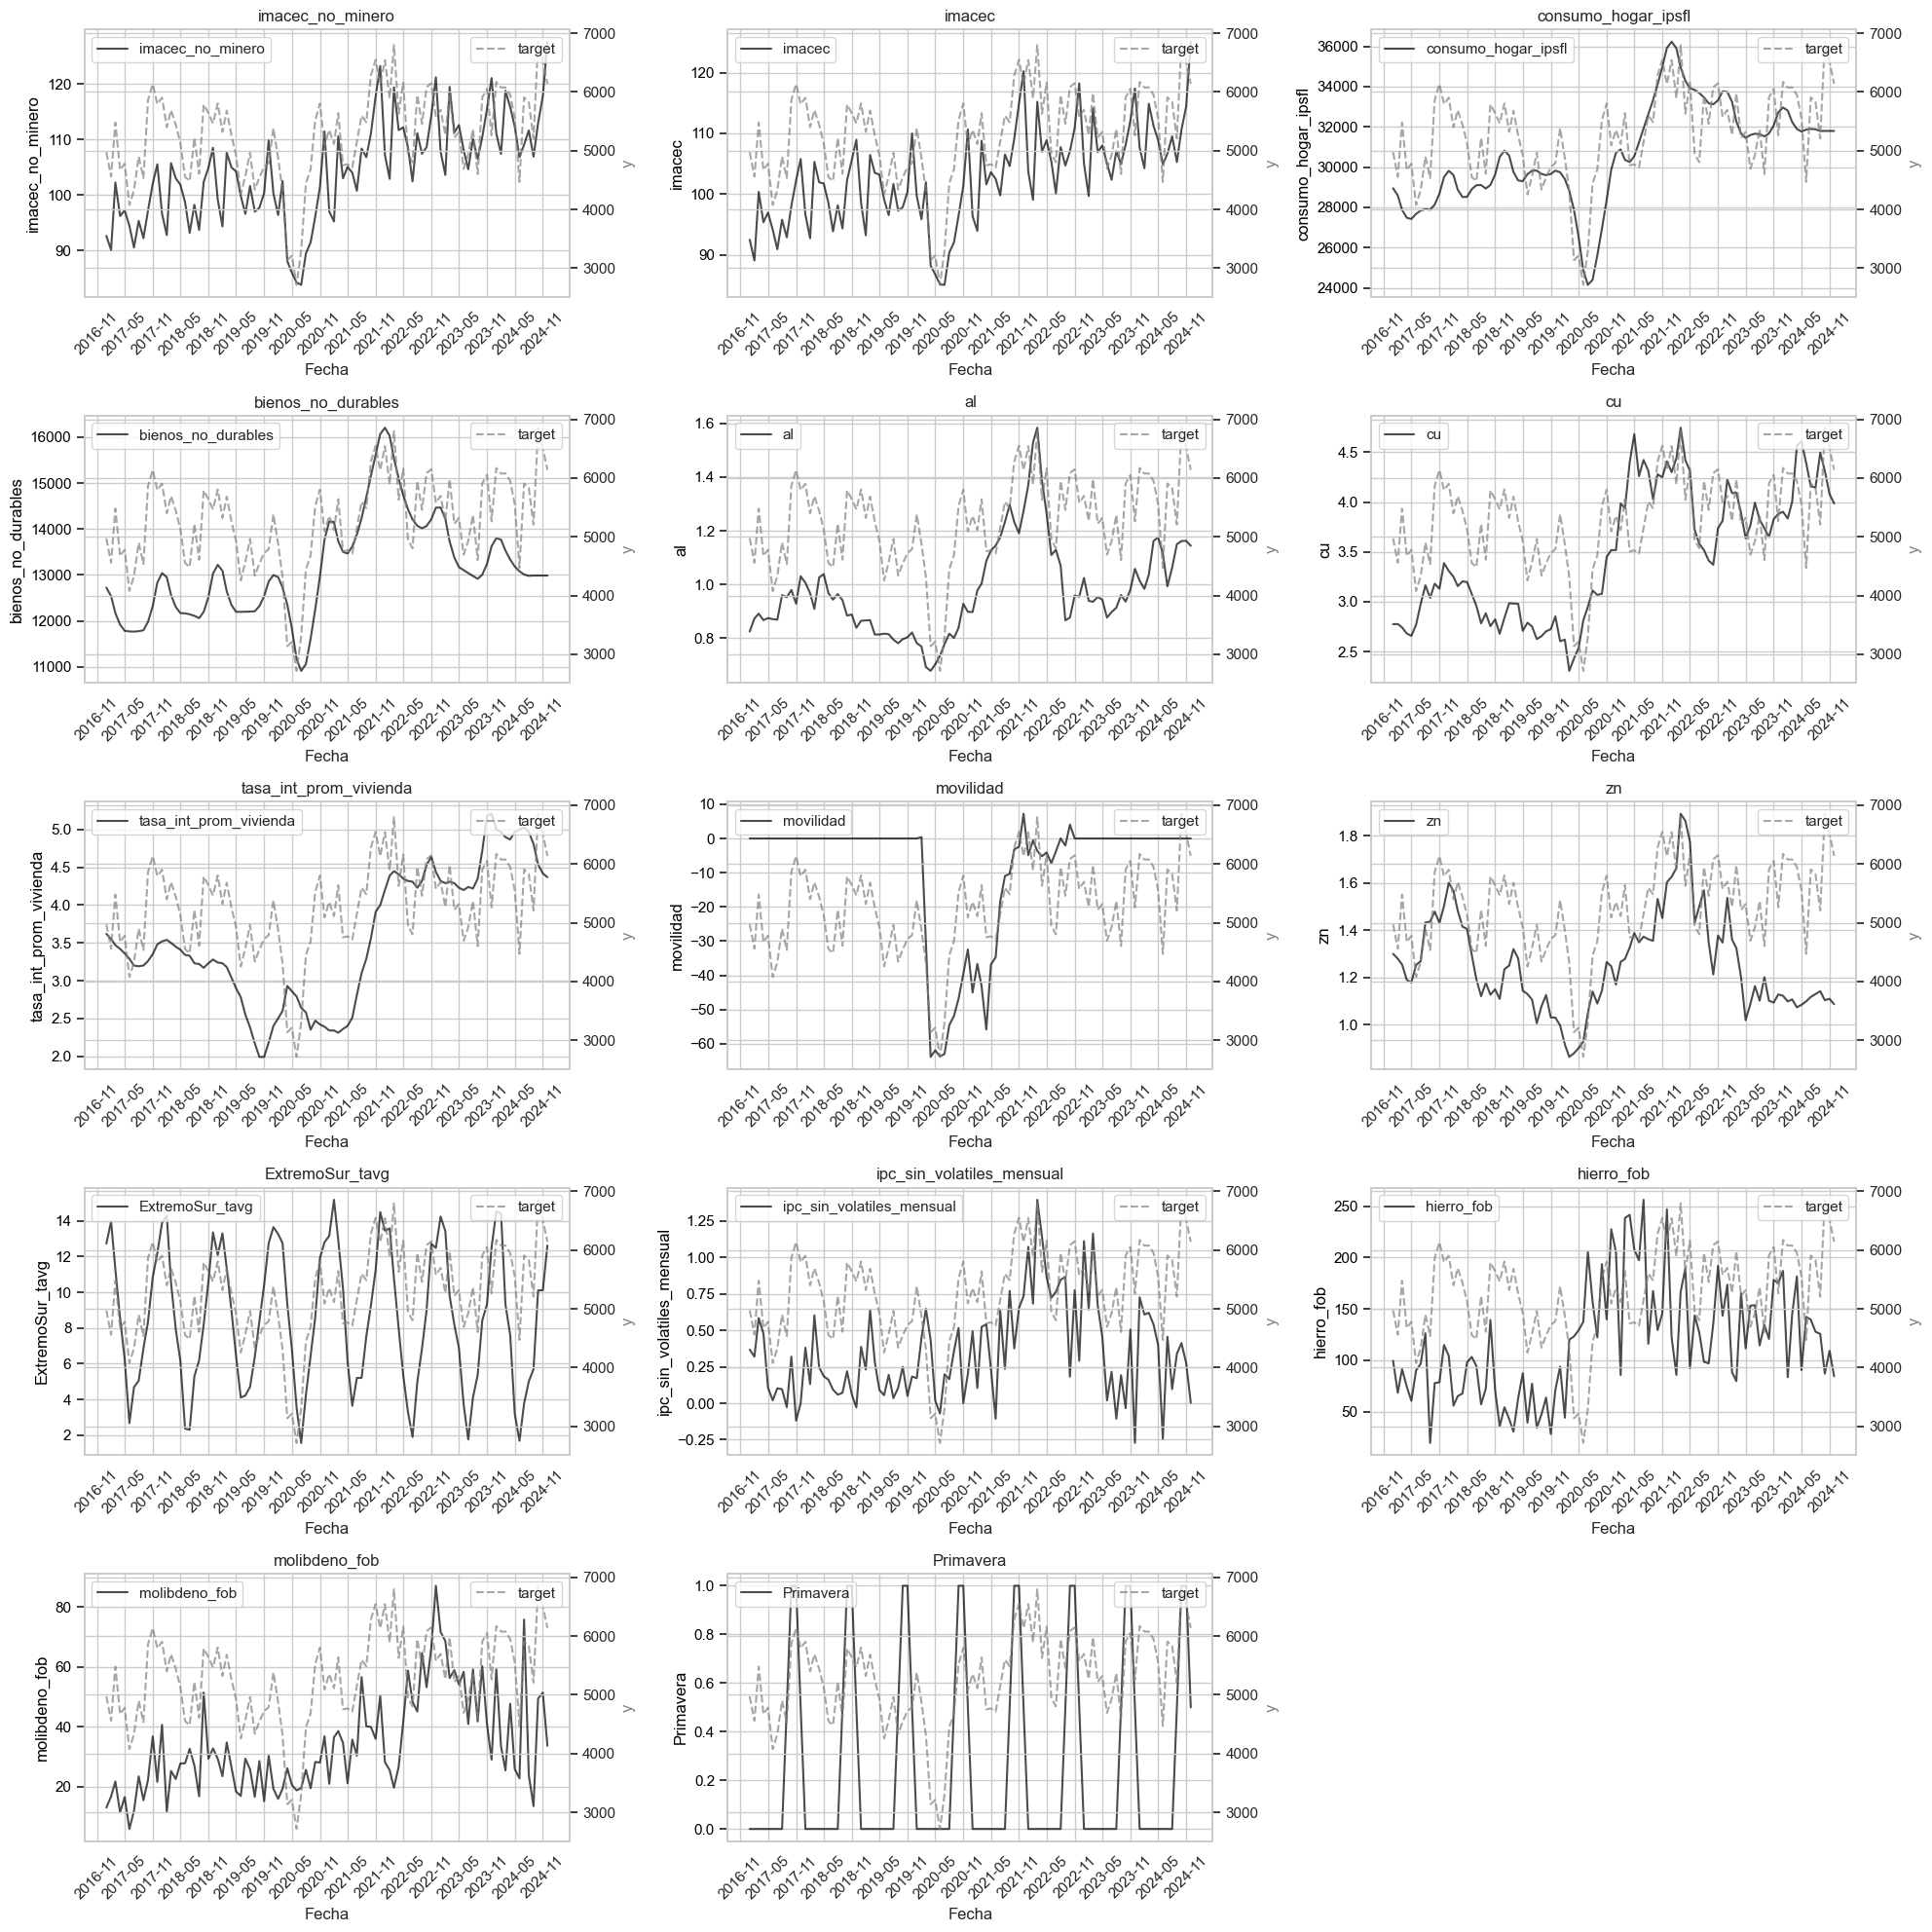

In [265]:
%matplotlib inline
plt.close('all') 
sns.set(style="whitegrid")
variables = features.variable.to_list()
cols = 3
rows = (len(variables) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4), squeeze=False)
axes = axes.flatten()
for idx, var in enumerate(variables):
    ax1 = axes[idx]
    sns.lineplot(x=df_final.index, y=df_final[var], ax=ax1,
                 label=var, color='black', alpha=0.7)
    ax1.set_xlabel('Fecha')
    ax1.set_ylabel(var, color='black')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.legend(loc='upper left')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax1.tick_params(axis='x', rotation=45)
    ax2 = ax1.twinx()
    sns.lineplot(x=df_final.index, y=df_final['y'], ax=ax2,
                 label='target', linestyle='--', color='gray', alpha=0.7)
    ax2.set_ylabel('y', color='gray')
    ax2.legend(loc='upper right')
    ax1.set_title(f'{var}')
for idx in range(len(variables), len(axes)):
    fig.delaxes(axes[idx])
fig.tight_layout()
plt.show()

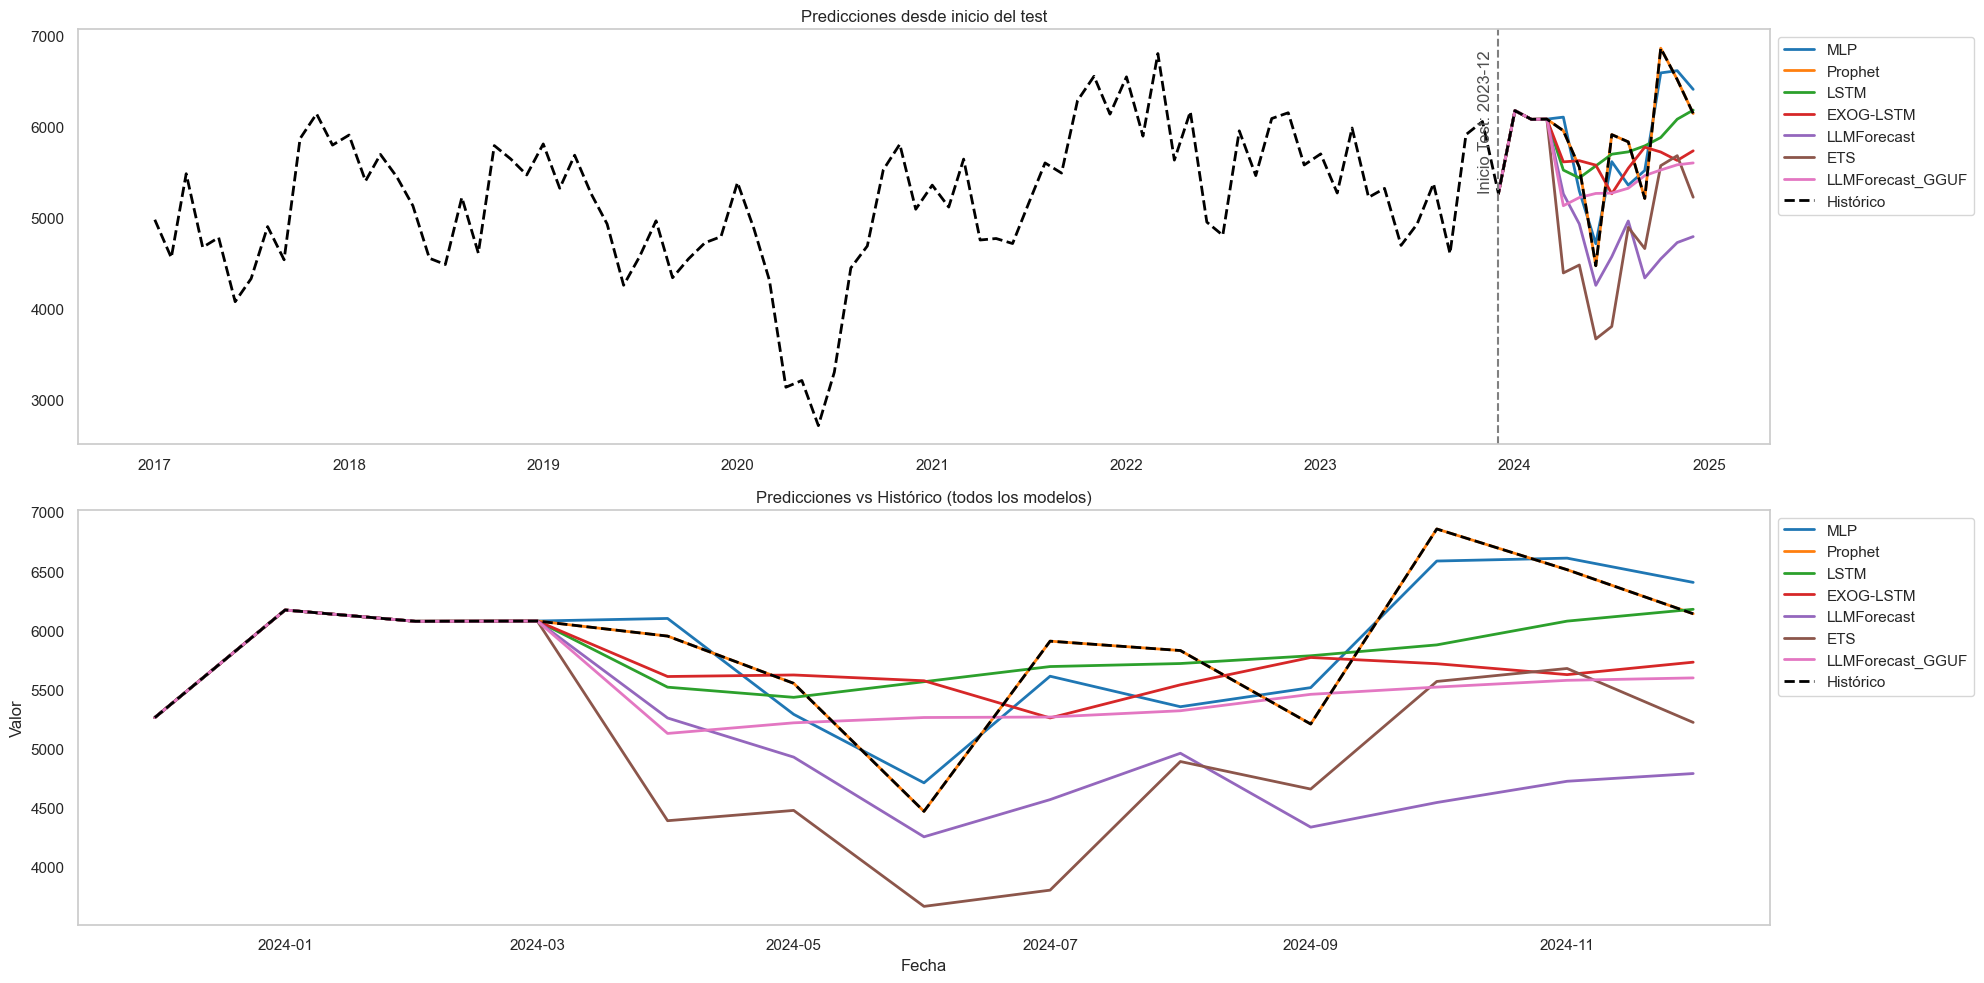

In [266]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
time_series = pd.DataFrame(df_final.copy()['y']).join(results.copy())
for i in results.columns:
    time_series[i] = time_series[i].fillna(time_series['y'])
modelos = [col for col in time_series.columns if col != 'y']
colores = sns.color_palette("tab10", n_colors=len(modelos))
fig, axes = plt.subplots(2, 1, figsize=(20, 10))
for modelo, color in zip(modelos, colores):
    pred = time_series[time_series.index >= start_test_date][modelo]
    axes[0].plot(pred.index, pred, label=modelo, color=color, linewidth=2)
axes[0].plot(
    time_series.index,
    time_series['y'],
    label="Histórico",
    color='black',
    linestyle='--',
    linewidth=2
)
axes[0].axvline(x=start_test_date, color='gray', linestyle='--')
axes[0].text(start_test_date - pd.Timedelta(days=25),
             axes[0].get_ylim()[1] * 0.75,
             start_test_date.strftime('Inicio Test: %Y-%m'),
             horizontalalignment='center', color='#505050', rotation=90)
axes[0].set_title("Predicciones desde inicio del test")
axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1))
axes[0].grid()
for color, model in zip(colores, results.columns):
    axes[1].plot(
        time_series.loc[str(start_test_date)::].index,
        time_series[model].loc[str(start_test_date)::],
        label=model,
        color=color,
        linestyle='-',
        linewidth=2
    )
axes[1].plot(
    time_series.loc[str(start_test_date)::].index,
    time_series['y'].loc[str(start_test_date)::],
    label="Histórico",
    color='black',
    linestyle='--',
    linewidth=2
)
axes[1].set_title("Predicciones vs Histórico (todos los modelos)")
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Valor')
axes[1].legend(loc='upper left', bbox_to_anchor=(1, 1))
axes[1].grid()
plt.tight_layout()
plt.show()